In [1]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from dreimac import ToroidalCoords, GeometryExamples, CircleMapUtils
from persim import plot_diagrams

# Theta shape

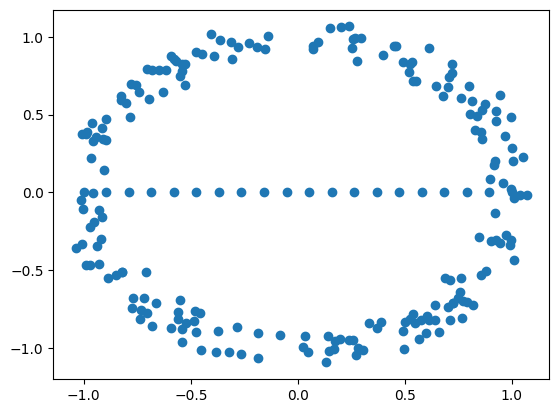

In [3]:
X1 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
X2 = np.zeros(shape=(20, 2))
X2[:, 0] = np.linspace(-1, 1, num =20)
X = np.vstack([X1, X2])
plt.scatter(X[:,0], X[:,1])

In [4]:
tc = ToroidalCoords(X, n_landmarks=220)

In [5]:
tc_theta = tc.get_coordinates(cocycle_idxs=[0,1])

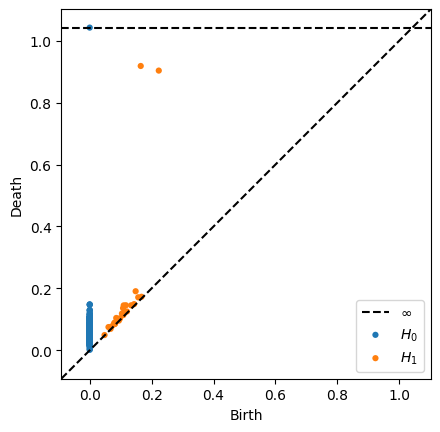

In [6]:
plot_diagrams(tc.dgms_)

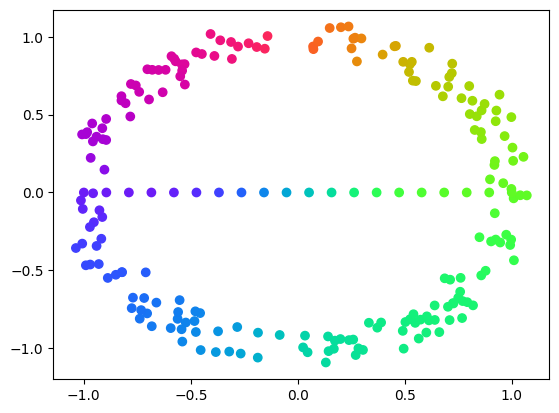

In [7]:
plt.scatter(X[:,0], X[:,1], c = CircleMapUtils.to_sinebow(tc_theta[1,:]))
#plt.scatter(X[tc._idx_land, 0], X[tc._idx_land, 1], color='black')

In [8]:
tc._idx_land

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

# Wedge of Circles

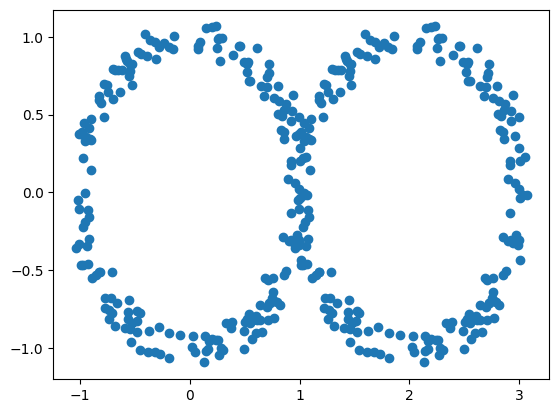

In [9]:
circ1 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
circ2 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
circ2[:,0] = circ2[:,0] + 2
X = np.vstack([circ1, circ2])
plt.scatter(X[:,0], X[:,1])

In [10]:
tc = ToroidalCoords(X, n_landmarks=400)
tc_theta = tc.get_coordinates(perc=0.15,cocycle_idxs=[0,1])

In [11]:
id_land = tc._idx_land

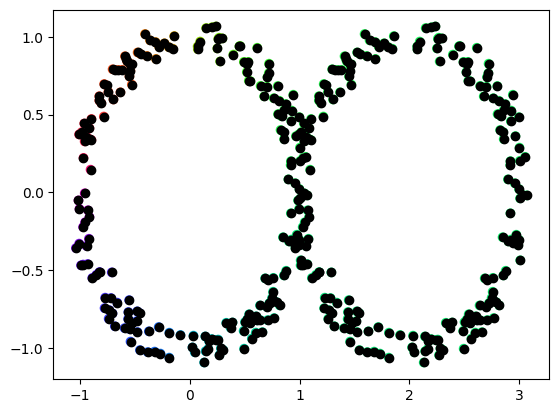

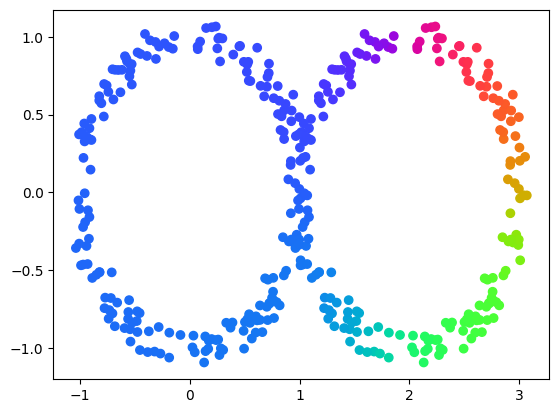

In [12]:
plt.scatter(X[:,0], X[:,1], c=CircleMapUtils.to_sinebow(tc_theta[0,:]))
plt.scatter(X[id_land,0], X[id_land,1], c="black")
plt.show()
plt.scatter(X[:,0], X[:,1], c=CircleMapUtils.to_sinebow(tc_theta[1,:]))

In [13]:
harm_reps_and_integrals = tc._harm_reps
harm_reps,_ = zip(*harm_reps_and_integrals)

In [14]:
from dreimac.utils import CohomologyUtils

theta = CohomologyUtils.one_cocycle_to_matrix(dist_mat=tc._dist_land_land, 
                                              threshold=tc._r_cover,
                                              lookup_table=tc._cns_lookup_table,
                                              n_points = tc._n_landmarks,
                                              cocycle_as_vector=harm_reps[0])


In [ ]:
row, column = *zip(theta.nonzero())

(array([  0,   0,   0, ..., 393, 396, 398], dtype=int32),
 array([  6,  44,  51, ..., 394, 397, 399], dtype=int32))

In [15]:
bad_idx = []
for i in range(len(theta)):
    vector = theta[i,:]
    

TypeError: sparse array length is ambiguous; use getnnz() or shape[0]